# Lab 7: พยากรณ์ผลผลิตลำไยจากค่าดิน (Regression)

**วิชา 11504233 ปัญญาประดิษฐ์สำหรับเกษตรอัจฉริยะ**

Lab 6 เราทำนาย **ประเภท** (พันธุ์ถั่วอะไร) เรียกว่า Classification
Lab นี้เราทำนาย **ตัวเลข** (ผลผลิตกี่ กก./ไร่) เรียกว่า **Regression**

โน้ตบุ๊กนี้เป็น **ภาคทดลอง** ของ Lab 7 คู่กับเว็บแอป `longan-system/app.py`
ที่นักศึกษาจะ deploy ขึ้น Streamlit — ในแอปเราแค่กด predict แล้วได้ตัวเลข
แต่ในโน้ตบุ๊กนี้เราจะเปิดฝากล่องดูว่า **โมเดลเรียนรู้อะไร และเชื่อได้แค่ไหน**

> **ที่มาของข้อมูล:** `lab07-longan-soil.csv` เป็นข้อมูล **สมมติ 80 สวน**
> สร้างจากสคริปต์ `_mkdata_4_longan.py` โดยอิงสรีรวิทยาลำไย
> ไม่ใช่ข้อมูลจริงจากสวน แต่ออกแบบให้แต่ละปัจจัย **แปรผันอิสระต่อกัน**
> เหมือนข้อมูลภาคสนามจริง จึงใช้ฝึกวิเคราะห์ได้อย่างมีความหมาย

# 1. โหลดข้อมูล

หนึ่งแถวคือ **หนึ่งสวนลำไย**

**ค่าดิน**
- `pH` - ความเป็นกรด-ด่างของดิน (ลำไยชอบ 5.5 - 6.5)
- `N` `P` `K` - ไนโตรเจน ฟอสฟอรัส โพแทสเซียม (mg/kg)
- `OM` - อินทรียวัตถุ (%)
- `moisture` - ความชื้นดิน (%)

**สภาพแวดล้อมและการจัดการ**
- `temp` - อุณหภูมิเฉลี่ย (องศาเซลเซียส)
- `rain` - ปริมาณน้ำฝน (มม./ปี)
- `density` - ความหนาแน่นการปลูก (ต้น/ไร่)
- `chlorate` - โพแทสเซียมคลอเรต (กก./ไร่) สารเร่งการออกดอกลำไยนอกฤดู

**สิ่งที่อยากทำนาย**
- `yield` - ผลผลิต (กก./ไร่)

In [14]:
import pandas as pd
import matplotlib.pyplot as plt


#เพิ่มโค้ด โหลดข้อมูลจากไฟล์ CSV 
df = pd.read_csv('./lab07-longan-soil.csv')
print(df.shape)
df.head()

(80, 11)


,pH,N,P,K,OM,moisture,temp,rain,density,chlorate,yield
0,6.6,34,31,136,2.2,61,28.4,1235,56,1.9,1056
1,5.4,60,36,122,0.6,72,26.9,706,62,8.0,926
2,6.6,57,11,185,3.2,77,31.5,1789,53,10.0,1106
3,5.2,73,13,199,2.2,55,23.8,1669,30,3.4,1094
4,5.1,71,42,176,0.8,76,25.2,819,46,0.3,799


In [15]:
df.describe().round(1)

,pH,N,P,K,OM,moisture,temp,rain,density,chlorate,yield
count,80.0,80.0,80.0,80.0,80.0,80.0,80.0,80.0,80.0,80.0,80.0
mean,5.9,50.7,24.3,171.8,2.5,56.8,28.2,1239.7,45.6,7.0,1037.0
std,0.8,21.8,10.4,54.1,1.1,13.5,2.7,357.5,15.4,4.2,160.8
min,4.6,15.0,8.0,90.0,0.6,33.0,23.6,666.0,19.0,0.1,645.0
25%,5.2,32.0,15.0,122.0,1.7,44.0,26.2,907.0,33.0,3.6,928.8
50%,6.0,55.0,22.5,172.0,2.7,57.0,28.0,1225.5,44.5,7.2,1061.5
75%,6.6,71.0,34.0,215.2,3.3,69.0,30.5,1535.8,58.0,10.2,1138.5
max,7.4,84.0,42.0,268.0,4.6,78.0,32.5,1818.0,72.0,14.9,1465.0


# 2. ดูข้อมูลก่อนสร้างโมเดล

**อย่าเพิ่งรีบสอนโมเดล** ดูก่อนว่าแต่ละปัจจัยสัมพันธ์กับผลผลิตแค่ไหน

`corr()` ให้ค่าสหสัมพันธ์ระหว่าง -1 ถึง 1
- ใกล้ **+1** = ปัจจัยเพิ่ม ผลผลิตเพิ่มตาม
- ใกล้ **-1** = ปัจจัยเพิ่ม ผลผลิตลด
- ใกล้ **0** = ไม่เกี่ยวกัน (หรือเกี่ยวแบบไม่เป็นเส้นตรง)

temp       -0.206
P          -0.101
moisture   -0.051
density     0.061
rain        0.088
pH          0.102
N           0.106
chlorate    0.371
OM          0.488
K           0.607


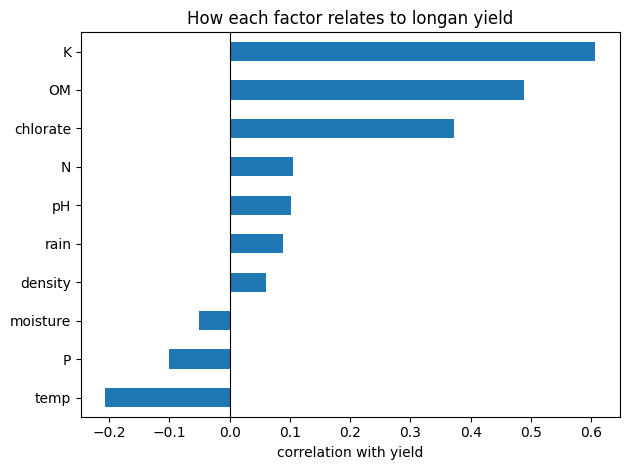

In [16]:
corr = df.corr()["yield"].drop("yield").sort_values()
print(corr.round(3).to_string())

corr.plot(kind="barh")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("correlation with yield")
plt.title("How each factor relates to longan yield")
plt.tight_layout()
plt.show()

อ่านกราฟได้ว่า **K (โพแทสเซียม) สัมพันธ์กับผลผลิตมากที่สุด** รองมาคือ OM และโพแทสเซียมคลอเรต
ซึ่งตรงกับความรู้เรื่องลำไย — โพแทสเซียมสำคัญต่อการติดผล และคลอเรตคือสารเร่งดอกนอกฤดู

ส่วน `temp` ติดลบ แปลว่าสวนที่ร้อนกว่าให้ผลผลิตน้อยกว่า

### ตรวจว่าปัจจัยสัมพันธ์กันเองหรือไม่

ข้อนี้สำคัญมาก ถ้าปัจจัยทุกตัวขึ้นลงพร้อมกันหมด (เรียกว่า **multicollinearity**)
โมเดลจะแยกไม่ออกว่าตัวไหนมีผลจริง ตีความผลลัพธ์ไม่ได้เลย

สหสัมพันธ์ระหว่างปัจจัยด้วยกันเอง: เฉลี่ย 0.098 | สูงสุด 0.240


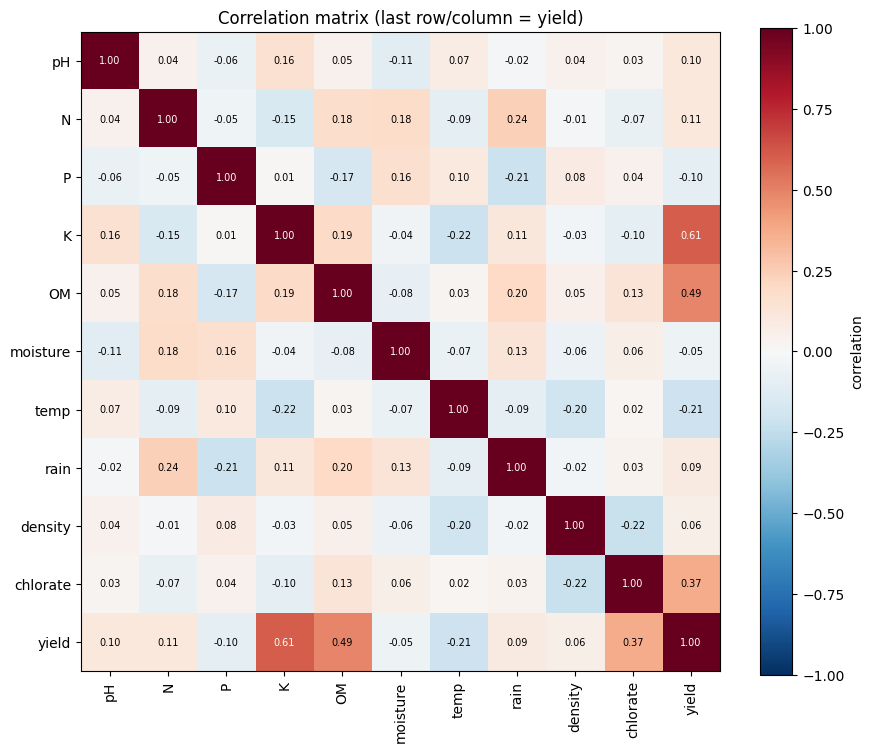

In [17]:
c = df.corr()                      # correlation matrix เต็ม รวม yield ด้วย
off = df.drop(columns=["yield"]).corr().abs().values
off = off[off < 0.999]
print("สหสัมพันธ์ระหว่างปัจจัยด้วยกันเอง: เฉลี่ย %.3f | สูงสุด %.3f" % (off.mean(), off.max()))

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(c, cmap="RdBu_r", vmin=-1, vmax=1)
fig.colorbar(im, label="correlation")

ax.set_xticks(range(len(c)), c.columns, rotation=90)
ax.set_yticks(range(len(c)), c.columns)

# เขียนตัวเลขลงในแต่ละช่อง
for i in range(len(c)):
    for j in range(len(c)):
        ค่า = c.iloc[i, j]
        ax.text(j, i, f"{ค่า:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(ค่า) > 0.55 else "black")

ax.set_title("Correlation matrix (last row/column = yield)")
plt.tight_layout()
plt.show()

ช่องนอกแนวทแยงมีสีอ่อนหมด (เฉลี่ยประมาณ 0.1) แปลว่า **แต่ละปัจจัยแปรผันอิสระต่อกัน**
เช่น มีทั้งสวนที่ pH ดีแต่ K ต่ำ และสวนที่ K สูงแต่ฝนน้อย

นี่คือสิ่งที่ข้อมูลชุดดีต้องมี ถ้าเก็บข้อมูลจริงแล้วค่านี้สูงใกล้ 1
แปลว่าเลือกสวนมาไม่หลากหลายพอ ต้องไปเก็บเพิ่ม

# 3. แบ่งข้อมูล

แยกเป็น **X** (ปัจจัยที่ใช้ทำนาย) และ **y** (สิ่งที่อยากรู้ = ผลผลิต)

แล้วแบ่งเป็น train (ใช้สอน) กับ test (ใช้สอบ) โมเดลต้องไม่เคยเห็นข้อมูล test มาก่อน
ไม่งั้นเหมือนให้ข้อสอบไปดูก่อนเข้าห้องสอบ

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["yield"])
y = df["yield"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#เพิ่มโค้ด แบ่งข้อมูลเป็นชุด train และ test
print("features:", X.shape[1], "| train:", len(X_train), "| test:", len(X_test))

features: 10 | train: 64 | test: 16


# 4. Feature Scaling

แต่ละคอลัมน์หน่วยต่างกันมาก `rain` เป็นหลักพัน แต่ `pH` มีแค่หลักหน่วย
ถ้าไม่ปรับสเกล โมเดลจะให้น้ำหนักคอลัมน์ตัวเลขใหญ่มากเกินจริง

**สำคัญ:** `fit` จากข้อมูล train เท่านั้น ถ้า fit จาก test ด้วยจะเป็น **data leakage**

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit จาก train เท่านั้น
X_test_s  = scaler.transform(X_test)        # test แค่ transform ห้าม fit ซ้ำ

# 5. สอนโมเดล

`LinearRegression` หาสมการที่ใกล้จุดข้อมูลทุกจุดมากที่สุด
ผลลัพธ์คือ `y = a1*x1 + a2*x2 + ... + b` ซึ่ง **อ่านได้ว่าปัจจัยไหนดันผลผลิตขึ้นหรือลง**

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier

#เพิ่มโค้ด สร้างโมเดล Linear Regression
model = LinearRegression()
#model = DecisionTreeRegressor()
model.fit(X_train, y_train)

LinearRegression()

# 6. ทำนายข้อมูล test

ให้โมเดลทำนายสวนที่ไม่เคยเห็นมาก่อน แล้วเทียบกับผลผลิตจริง

In [21]:
y_predict = model.predict(X_test_s)

เทียบ = pd.DataFrame({
    "ผลผลิตจริง": y_test,
    "โมเดลทาย": y_predict.round(0),
    "ห่างจากจริง": (y_predict - y_test).round(0),
})
print(เทียบ.head(10).to_string(index=False))
print()
print("ทายสูงเกินจริง", (เทียบ["ห่างจากจริง"] > 0).sum(), "สวน |",
      "ทายต่ำเกินจริง", (เทียบ["ห่างจากจริง"] < 0).sum(), "สวน")

 ผลผลิตจริง  โมเดลทาย  ห่างจากจริง
       1084     605.0       -479.0
       1056     539.0       -517.0
       1127     621.0       -506.0
        929     601.0       -328.0
        854     603.0       -251.0
       1105     611.0       -494.0
        831     609.0       -222.0
       1206     619.0       -587.0
        799     532.0       -267.0
       1143     642.0       -501.0

ทายสูงเกินจริง 0 สวน | ทายต่ำเกินจริง 16 สวน


d:\python 3.8.8\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# 7. ทดสอบประสิทธิภาพ

Regression ใช้ Accuracy ไม่ได้ เพราะทำนายตัวเลข ไม่มีทางตรงเป๊ะ ต้องวัดว่า **ห่างแค่ไหน**

- **R2** อธิบายความแปรปรวนได้กี่ % (1.0 = สมบูรณ์แบบ, 0 = ไม่ดีกว่าเดาค่าเฉลี่ย)
- **MAE** ค่าเฉลี่ยที่ทำนายพลาด หน่วยเดียวกับผลผลิต (กก./ไร่) อ่านง่ายที่สุด
- **RMSE** คล้าย MAE แต่ **ลงโทษความผิดพลาดครั้งใหญ่หนักกว่า**

กราฟ: แต่ละจุดคือหนึ่งสวน ถ้าโมเดลดี จุดจะเกาะเส้นประ

R2   = -7.264
MAE  = 406.0 kg/rai
RMSE = 429.4 kg/rai
เทียบกับผลผลิตเฉลี่ย 1037 kg/rai -> พลาดประมาณ 39.2 %


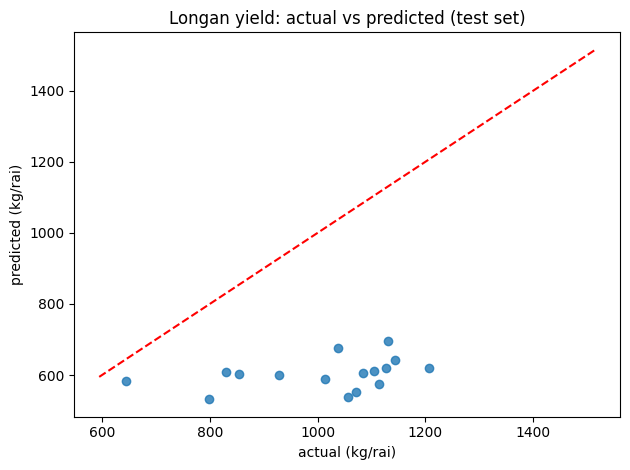

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R2   =", round(r2_score(y_test, y_predict), 3))
print("MAE  =", round(mean_absolute_error(y_test, y_predict), 1), "kg/rai")
print("RMSE =", round(mean_squared_error(y_test, y_predict) ** 0.5, 1), "kg/rai")
print("เทียบกับผลผลิตเฉลี่ย", round(y.mean()), "kg/rai -> พลาดประมาณ",
      round(mean_absolute_error(y_test, y_predict) / y.mean() * 100, 1), "%")

lo, hi = y.min() - 50, y.max() + 50
plt.scatter(y_test, y_predict, alpha=0.8)
plt.plot([lo, hi], [lo, hi], "r--")
plt.xlabel("actual (kg/rai)")
plt.ylabel("predicted (kg/rai)")
plt.title("Longan yield: actual vs predicted (test set)")
plt.tight_layout()
plt.show()

# 8. อ่านสมการ: ปัจจัยไหนดันผลผลิตขึ้น

เพราะปรับสเกลมาแล้ว ค่าสัมประสิทธิ์จึงเทียบกันได้ตรง ๆ
ตัวเลขแปลว่า **ถ้าปัจจัยนั้นเพิ่มขึ้น 1 ส่วนเบี่ยงเบนมาตรฐาน ผลผลิตเปลี่ยนกี่ กก./ไร่**

pH         -25.2
P           -1.7
moisture    -0.6
rain        -0.1
temp         0.5
density      1.6
N            2.0
K            2.1
chlorate    18.1
OM          39.0


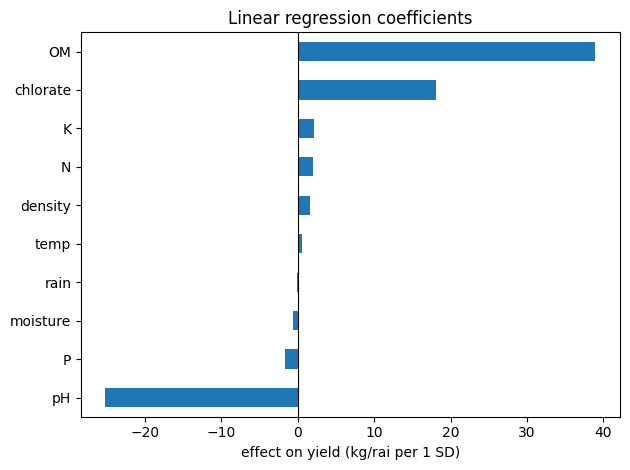

In [23]:
coef = pd.Series(model.coef_, index=X.columns).sort_values()
print(coef.round(1).to_string())

coef.plot(kind="barh")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("effect on yield (kg/rai per 1 SD)")
plt.title("Linear regression coefficients")
plt.tight_layout()
plt.show()

K, โพแทสเซียมคลอเรต และ OM เป็นบวกและใหญ่ที่สุด — ตรงกับความรู้เรื่องลำไย

**ข้อควรระวัง:** ค่าสัมประสิทธิ์ของ `pH` `temp` `moisture` ออกมาเกือบศูนย์
ไม่ได้แปลว่าไม่สำคัญ แต่เพราะปัจจัยพวกนี้มีผลแบบ **ระฆังคว่ำ** (มีช่วงเหมาะสม
น้อยไปก็ไม่ดี มากไปก็ไม่ดี) ซึ่งเส้นตรงจับความสัมพันธ์แบบนี้ไม่ได้ — ดูขั้นที่ 10

# 9. เปรียบเทียบโมเดล

`DummyRegressor` ทายค่าเฉลี่ยเสมอ ไม่ได้เรียนรู้อะไรเลย เป็น **เส้นมาตรฐานขั้นต่ำ**
โมเดลที่ใช้ได้จริงต้องชนะ Dummy ให้ได้ ไม่งั้นก็ไม่ต้องทำโมเดล

เพิ่ม **5-fold cross-validation** ด้วย คือแบ่งข้อมูลเป็น 5 กลุ่ม
ผลัดกันเป็น test ครบทุกกลุ่มแล้วเฉลี่ย — น่าเชื่อถือกว่าแบ่งครั้งเดียว

In [24]:
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, KFold

models = [("Dummy(ค่าเฉลี่ย)", DummyRegressor()),
          ("LinearRegression", LinearRegression()),
          ("DecisionTree", DecisionTreeRegressor(random_state=123)),
          ("RandomForest", RandomForestRegressor(random_state=123))]

cv = KFold(5, shuffle=True, random_state=42)
print(f"{'model':20} {'R2(test)':>9} {'MAE(test)':>10} {'MAE(5-fold)':>12}")
for name, m in models:
    pipe = make_pipeline(StandardScaler(), m).fit(X_train, y_train)
    p = pipe.predict(X_test)
    cvmae = -cross_val_score(make_pipeline(StandardScaler(), m), X, y,
                             cv=cv, scoring="neg_mean_absolute_error").mean()
    print(f"{name:20} {r2_score(y_test, p):9.3f} {mean_absolute_error(y_test, p):10.1f} {cvmae:12.1f}")

model                 R2(test)  MAE(test)  MAE(5-fold)
Dummy(ค่าเฉลี่ย)        -0.054      114.9        126.3
LinearRegression         0.488       77.9         72.9
DecisionTree             0.245       89.9        102.6
RandomForest             0.485       81.7         84.3


**DecisionTree ต้นเดียวแย่กว่า RandomForest ชัดเจน** เพราะต้นเดียวจำข้อมูล train
จนเกินไป (overfitting) ส่วน RandomForest เฉลี่ยจากหลายต้นเลยนิ่งกว่า

ส่วน LinearRegression ทำได้ดีเพราะข้อมูลชุดนี้ผลของแต่ละปัจจัยรวมกันแบบบวก
ถ้าข้อมูลจริงมีความสัมพันธ์ซับซ้อนกว่านี้ RandomForest มักจะชนะ